## Interpolation of the return with a polynomial to build a new feature

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

### Read files & submission file for template

In [2]:
X_train = pd.read_csv('../data/X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('../data/X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('../data/y_train.csv',index_col='ROW_ID')
y_train_clf = pd.DataFrame((y_train['target']>0).astype(int))
sample_submission = pd.read_csv('../submissions/sample_submission.csv',index_col='ROW_ID')

In [3]:
X_train.head(10)

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4
5,DATE_0001,ALLOCATION_06,0.005324,-0.000261,0.000329,0.002983,0.003300,-0.003082,-0.004202,0.001252,...,-1.982755,-1.291189,-1.676275,-0.959473,-0.831422,-0.975812,-0.081688,0.091693,0.649944,1
6,DATE_0001,ALLOCATION_07,-0.001348,0.000755,0.000806,0.003347,0.000798,-0.001033,0.001150,0.001335,...,-1.334282,-1.029506,-1.404410,-1.037167,-1.421681,-1.733141,-1.347334,NaN,0.181928,4
7,DATE_0001,ALLOCATION_08,0.002332,0.000915,0.000210,-0.004180,-0.001825,-0.000418,0.002025,-0.000007,...,-2.945963,-1.161804,1.716116,1.228808,0.162562,1.184663,1.813697,NaN,0.004543,3
8,DATE_0001,ALLOCATION_09,0.003805,0.002004,-0.001503,0.000572,0.003247,-0.001319,0.000674,0.000188,...,-1.024061,-0.967030,-0.850383,-0.583060,-1.549293,-0.655051,-0.354758,NaN,0.012351,3


### Features

In [4]:
RET_features = [f'RET_{i}' for i in range(1,21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

### Fitting the regression (Cubic Spline Interpolation)

In [5]:
from scipy.interpolate import CubicSpline

Forecast RET_1, RET_2: [0.0042147  0.00266459]
Actual   RET_1, RET_2: [ 0.00394441 -0.00017808]


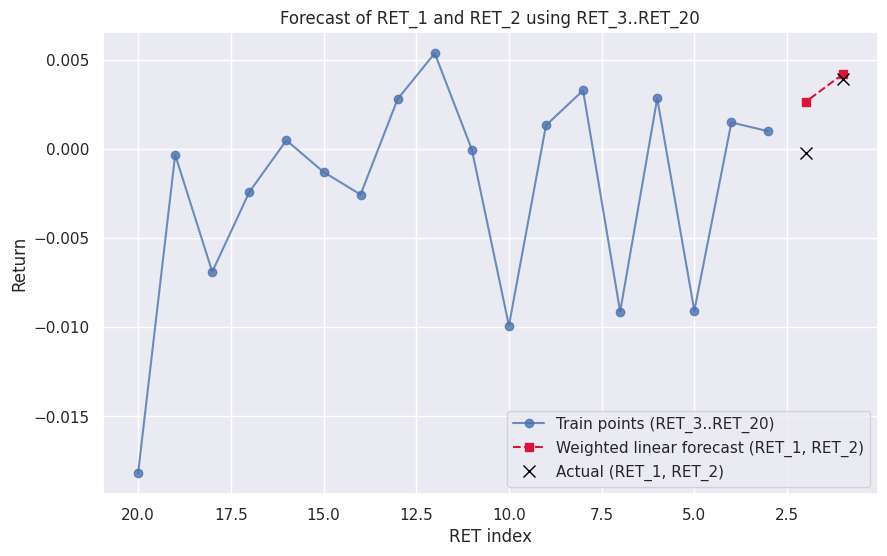

In [27]:
# Example series: first training row (ordered as RET_1 ... RET_20)
returns_test = X_train[RET_features].iloc[0, :].to_numpy()
x = np.arange(1, 21)

# Fit on RET_3..RET_20 (indices 3..20)
x_fit = x[2:]
y_fit = returns_test[2:]

# Exponential weights: give higher weight to points closer to forecast side (x=1,2)
decay_rate = 0.5
weights = np.exp(-decay_rate * (x_fit - x_fit.min()))

# Weighted linear regression (degree 1)
m, b = np.polyfit(x_fit, y_fit, deg=1, w=weights)

# Forecast RET_1 and RET_2
x_forecast = np.array([1, 2])
y_forecast = m * x_forecast + b

print("Forecast RET_1, RET_2:", y_forecast)
print("Actual   RET_1, RET_2:", returns_test[0:2])

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_fit, y_fit, 'o-', label='Train points (RET_3..RET_20)', alpha=0.8)
plt.plot(x_forecast, y_forecast, 's--', label='Weighted linear forecast (RET_1, RET_2)', color='crimson')
plt.plot(x_forecast, returns_test[0:2], 'x', label='Actual (RET_1, RET_2)', color='black', markersize=9)
plt.xlabel('RET index')
plt.ylabel('Return')
plt.title('Forecast of RET_1 and RET_2 using RET_3..RET_20')
plt.legend()
plt.gca().invert_xaxis()  # smaller indices on the right
plt.show()

### Testing the interpolation compared to just guessing the return is the same as t-1

In [ ]:
def weighted_linear_forecast_ret1(series, degree=1, decay_rate=0.5):
    series = np.asarray(series, dtype=float)
    x = np.arange(1, len(series) + 1)

    # Fit on RET_2..RET_20 (all points except the first one)
    x_fit = x[1:]
    y_fit = series[1:]

    # Remove NaNs before fitting
    mask = ~np.isnan(y_fit)
    x_fit = x_fit[mask]
    y_fit = y_fit[mask]

    # Not enough data to fit the chosen polynomial degree
    if len(y_fit) <= degree:
        return np.nan

    # Higher weight on points closer to RET_1 (i.e., smaller x among x_fit)
    weights = np.exp(-decay_rate * (x_fit - x_fit.min()))
    coeffs = np.polyfit(x_fit, y_fit, deg=degree, w=weights)

    # Forecast RET_1
    x_forecast = 1
    y_forecast = np.polyval(coeffs, x_forecast)

    return y_forecast


def add_weighted_forecast_feature(df, ret_columns, output_col='RET_1_forecast', degree=1, decay_rate=0.5):
    df = df.copy()
    df[output_col] = df[ret_columns].apply(
        lambda row: weighted_linear_forecast_ret1(row.values, degree=degree, decay_rate=decay_rate),
        axis=1
    )
    return df

In [44]:
X_train = add_weighted_forecast_feature(
    X_train,
    RET_features,
    output_col='RET_1_forecast',
    degree=1,
    decay_rate=0.2
)

X_train[['RET_1', 'RET_2', 'RET_1_forecast']].head()

,RET_1,RET_2,RET_1_forecast
ROW_ID,,,
0,0.003944,-0.000178,0.000287
1,0.002323,0.000670,0.000291
2,-0.000238,-0.002696,-0.003025
3,0.001863,0.001234,-0.001213
4,0.001219,-0.001040,-0.002511


In [43]:
accuracy_forecast = np.mean(np.sign(X_train['RET_1_forecast']) == np.sign(X_train['RET_1']))
print(f"Accuracy of RET_1 forecast sign: {accuracy_forecast:.4f}")

accuracy_constant = np.mean(np.sign(X_train['RET_2']) == np.sign(X_train['RET_1']))
print(f"Accuracy of constant forecast (RET_2 as forecast): {accuracy_constant:.4f}")

diff_forecast_constant = np.mean(np.sign(X_train['RET_1_forecast']) == np.sign(X_train['RET_2']))
print(f"Agreement in sign between forecast and constant (RET_2): {diff_forecast_constant:.4f}")

accuracy_always_pos = np.mean(np.sign(1) == np.sign(X_train['RET_1']))
print(f"Accuracy of always predicting positive: {accuracy_always_pos:.4f}")

Accuracy of RET_1 forecast sign: 0.5144
Accuracy of constant forecast (RET_2 as forecast): 0.5144
Agreement in sign between forecast and constant (RET_2): 0.9526
Accuracy of always predicting positive: 0.5117
